### <CENTER> GOLD PURITY ESTIMATOR </CENTER>

#### Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
IMAGE_PATH = "images/prototype/"

#### Volume Measurement - Prototype

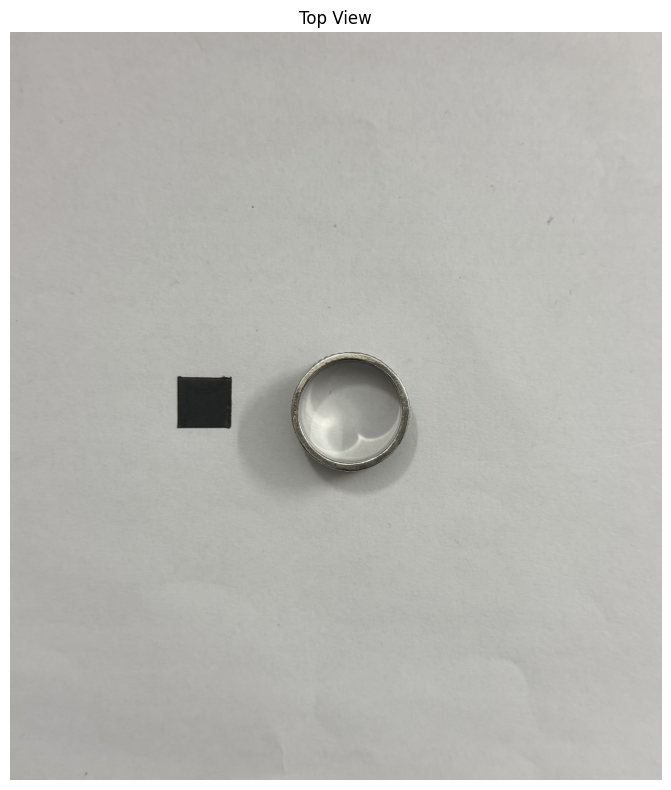

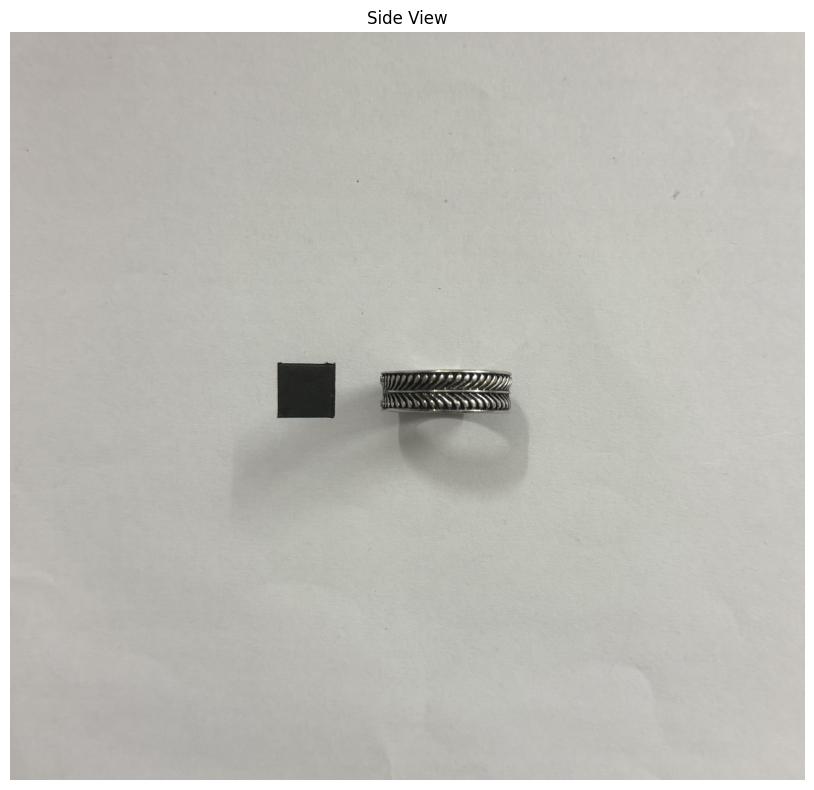

In [3]:
# power bank
# top_view_path = IMAGE_PATH + "IMG_0331.jpeg"
# side_view_path = IMAGE_PATH + "IMG_0303.jpeg"

# ring
top_view_path = IMAGE_PATH + "IMG_0326.jpeg"
side_view_path = IMAGE_PATH + "IMG_0330.jpeg"

# pyramid
# top_view_path = IMAGE_PATH + "IMG_0321.jpeg"
# side_view_path = IMAGE_PATH + "IMG_0322.jpeg"

# cap
# top_view_path = IMAGE_PATH + "IMG_0843.jpeg"
# side_view_path = IMAGE_PATH + "IMG_0844.jpeg"

top_view = cv2.imread(top_view_path)
side_view = cv2.imread(side_view_path)

if top_view is None:
    print(f"Error: Could not load image from {top_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(top_view, cv2.COLOR_BGR2RGB))
    plt.title("Top View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if side_view is None:
    print(f"Error: Could not load image from {side_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(side_view, cv2.COLOR_BGR2RGB))
    plt.title("Side View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
from backend.gold_estimator.volume import detect_reference_square


def compute_scale_from_ref(img, real_size_cm=1.0, debug=True):
    """Estimate cm-per-pixel scale from the 1 cm reference square.

    Uses the backend detector so the notebook and API stay aligned.
    Returns:
        scale (float): centimeters per pixel
        pixel_width (float): detected marker width in pixels
        ref_bbox (tuple): marker bounding box as (x, y, w, h)
    """
    scale, pixel_width, ref_bbox = detect_reference_square(img, real_size_cm=real_size_cm)

    if debug:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        x, y, w, h = ref_bbox
        img_vis = img.copy()
        cv2.rectangle(img_vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(
            img_vis,
            f"Ref: {pixel_width:.1f} px | Scale: {scale:.6f} cm/px",
            (x, max(20, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2,
        )

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
        plt.title("Reference Square Detection")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return scale, pixel_width, ref_bbox


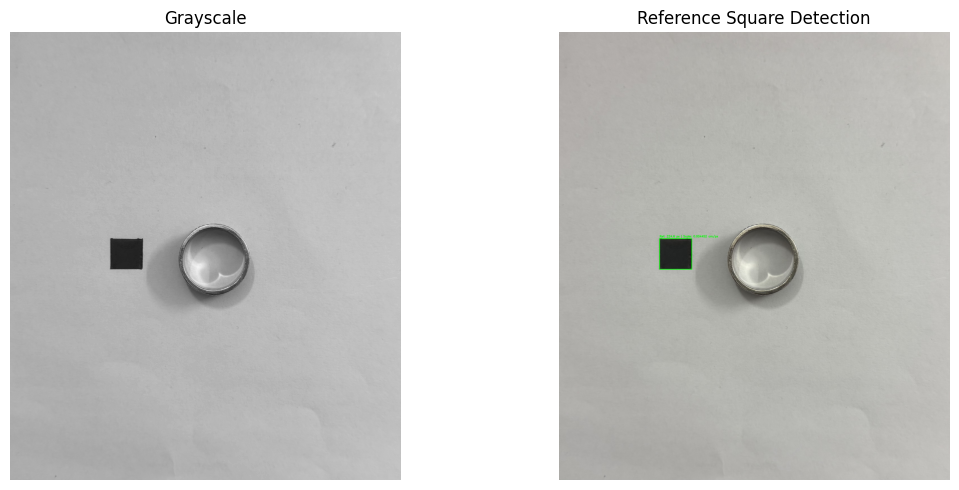

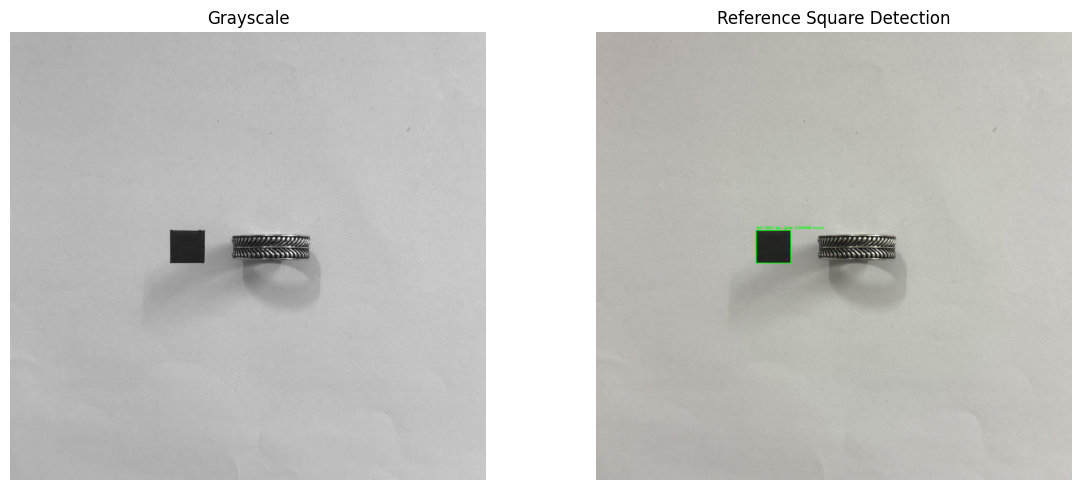

Top scale:  0.004452 cm/pixel
Side scale: 0.004839 cm/pixel
Scale mismatch (%): 8.33%


In [5]:
top_scale_cm, top_ref_size_px, top_ref_bbox = compute_scale_from_ref(top_view, real_size_cm=1.0, debug=True)
side_scale_cm, side_ref_size_px, side_ref_bbox = compute_scale_from_ref(side_view, real_size_cm=1.0, debug=True)

print(f"Top scale:  {top_scale_cm:.6f} cm/pixel")
print(f"Side scale: {side_scale_cm:.6f} cm/pixel")
print(f"Scale mismatch (%): {abs(top_scale_cm - side_scale_cm) / ((top_scale_cm + side_scale_cm)/2) * 100:.2f}%")


In [6]:
from backend.gold_estimator.volume import segment_object_prototype


def segment_object(img, view_name="view", debug=True, ref_square_size_px=None, ref_square_bbox=None, bg_similarity=0.80,
                   close_iterations=2, edge_low=50, edge_high=150,
                   segmentation_mode="robust",  # "robust" | "auto" | "edge" | "threshold"
                   allow_holes=True, shadow_suppression=True, edge_support_min_ratio=0.06, min_component_area=250,
                   ):
    """Segment object material with a reflection-robust default mode.

    The robust mode now uses a hybrid strategy. Bright or colorful objects
    are segmented from paper using LAB chroma difference and a tight local
    refinement crop, while lower-chroma matte objects fall back to the older
    threshold-plus-edge path, which is less likely to absorb nearby shadows.
    """
    seg = segment_object_prototype(
        img,
        ref_square_size_px=int(round(ref_square_size_px)) if ref_square_size_px is not None else None,
        ref_bbox=ref_square_bbox,
        bg_similarity=bg_similarity,
        close_iterations=close_iterations,
        edge_low=edge_low,
        edge_high=edge_high,
        segmentation_mode=segmentation_mode,
        allow_holes=allow_holes,
        shadow_suppression=shadow_suppression,
        edge_support_min_ratio=edge_support_min_ratio,
        min_component_area=min_component_area,
    )

    if debug:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        overlay = img.copy()
        cv2.drawContours(overlay, [seg["contour"]], -1, (0, 255, 255), 2)
        for hc in seg["holes"]:
            cv2.drawContours(overlay, [hc], -1, (255, 0, 255), 2)
        cv2.drawContours(overlay, [seg["hull"]], -1, (0, 255, 0), 2)
        if ref_square_bbox is not None:
            x, y, w, h = ref_square_bbox
            cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 128, 0), 2)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title(f"{view_name}: Grayscale")
        axes[0].axis('off')

        axes[1].imshow(seg["mask"], cmap='gray')
        axes[1].set_title(f"{view_name}: Final Material Mask")
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f"{view_name}: Robust Boundaries")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    return seg


def compute_volume_from_boundaries(top_seg, side_seg, top_scale_cm, side_scale_cm, debug=True, n_slices=120):
    """Estimate volume using slice-wise height integration.

    Method:
    1) Build a top-view area profile across normalized x.
    2) Build a side-view height profile across normalized x.
    3) Compute weighted mean height from these profiles.
    4) Volume = total top material area * weighted mean height.
    """
    top_mask = top_seg["mask"]
    side_mask = side_seg["mask"]

    top_area_px = cv2.countNonZero(top_mask)
    if top_area_px == 0:
        raise ValueError("Top mask is empty.")

    top_area_cm2 = top_area_px * (top_scale_cm ** 2)

    top_x = np.where(np.sum(top_mask > 0, axis=0) > 0)[0]
    side_x = np.where(np.sum(side_mask > 0, axis=0) > 0)[0]
    if len(top_x) == 0 or len(side_x) == 0:
        raise ValueError("Could not extract x-profiles from masks.")

    u = np.linspace(0, 1, n_slices)
    top_cols = np.round(top_x[0] + u * (top_x[-1] - top_x[0])).astype(int)
    side_cols = np.round(side_x[0] + u * (side_x[-1] - side_x[0])).astype(int)

    top_area_profile_px = np.array([np.count_nonzero(top_mask[:, x]) for x in top_cols], dtype=float)

    side_height_profile_px = []
    for x in side_cols:
        ys = np.where(side_mask[:, x] > 0)[0]
        h = (ys.max() - ys.min() + 1) if len(ys) > 0 else 0
        side_height_profile_px.append(h)
    side_height_profile_px = np.array(side_height_profile_px, dtype=float)

    if n_slices >= 7:
        kernel = np.ones(5, dtype=float) / 5.0
        top_area_profile_px = np.convolve(top_area_profile_px, kernel, mode="same")
        side_height_profile_px = np.convolve(side_height_profile_px, kernel, mode="same")

    weights = top_area_profile_px
    if np.sum(weights) <= 0:
        raise ValueError("Top area profile is empty after processing.")
    weights = weights / np.sum(weights)

    side_height_profile_cm = side_height_profile_px * side_scale_cm
    avg_height_cm = float(np.sum(weights * side_height_profile_cm))
    volume_cm3 = top_area_cm2 * avg_height_cm

    print(f"Estimated top area: {top_area_cm2:.4f} cm^2 ({top_area_px:.0f} px^2)")
    print(f"Estimated side height: {avg_height_cm:.4f} cm")
    print(f"Estimated volume: {volume_cm3:.4f} cm^3")

    if debug:
        ys, xs = np.where(side_mask > 0)
        y_min = int(np.min(ys)) if len(ys) else 0
        y_max = int(np.max(ys)) if len(ys) else 0

        top_vis = cv2.cvtColor(top_mask, cv2.COLOR_GRAY2BGR)
        side_vis = cv2.cvtColor(side_mask, cv2.COLOR_GRAY2BGR)

        top_contours, top_hier = cv2.findContours(top_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
        if top_hier is not None:
            top_hier = top_hier[0]
            for i, c in enumerate(top_contours):
                color = (0, 255, 255) if top_hier[i][3] == -1 else (255, 0, 255)
                cv2.drawContours(top_vis, [c], -1, color, 2)

        x_med = int(np.median(xs)) if len(xs) else 0
        cv2.line(side_vis, (x_med, y_min), (x_med, y_max), (0, 0, 255), 2)
        cv2.putText(
            side_vis,
            f"Avg Height: {avg_height_cm:.2f} cm",
            (x_med + 8, max(y_min + 20, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2,
        )

        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        axes[0].imshow(cv2.cvtColor(top_vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Top Mask")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(side_vis, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Side Mask")
        axes[1].axis('off')

        axes[2].plot(u, side_height_profile_cm, color='tab:red', linewidth=2, label='Height profile')
        axes[2].axhline(avg_height_cm, color='k', linestyle='--', label=f'Weighted mean = {avg_height_cm:.2f} cm')
        axes[2].set_title("Slice-wise Height Profile")
        axes[2].set_xlabel("Normalized width")
        axes[2].set_ylabel("Height (cm)")
        axes[2].grid(alpha=0.3)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    return volume_cm3


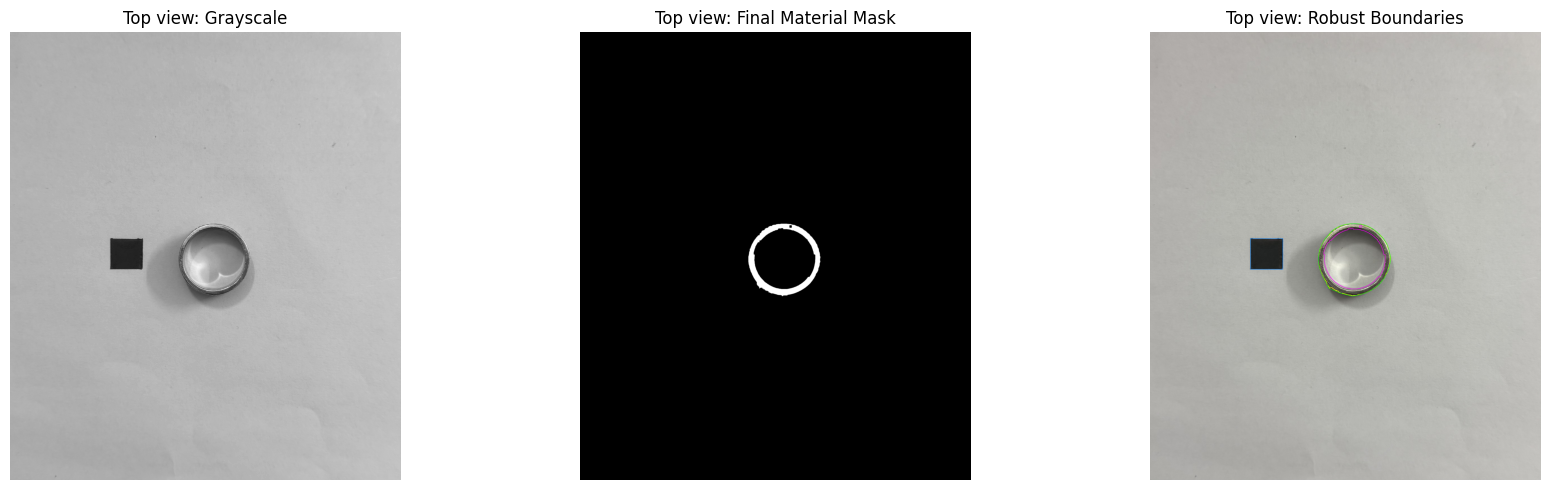

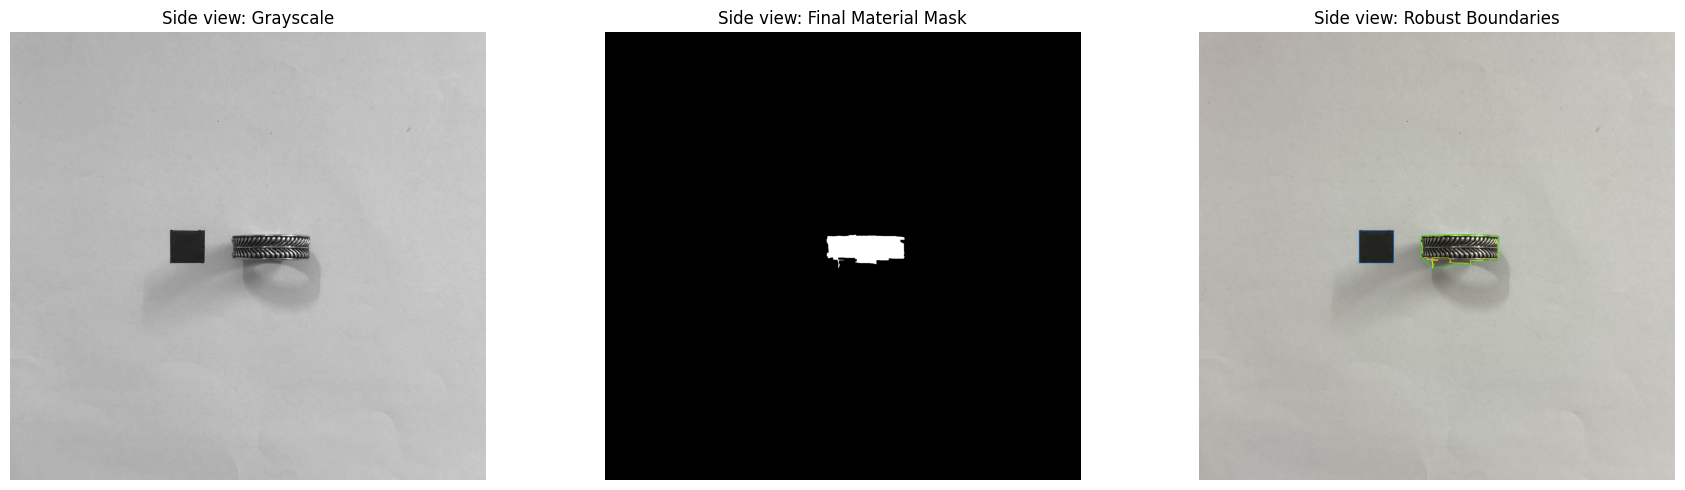

Estimated top area: 1.1543 cm^2 (58250 px^2)
Estimated side height: 0.7047 cm
Estimated volume: 0.8135 cm^3


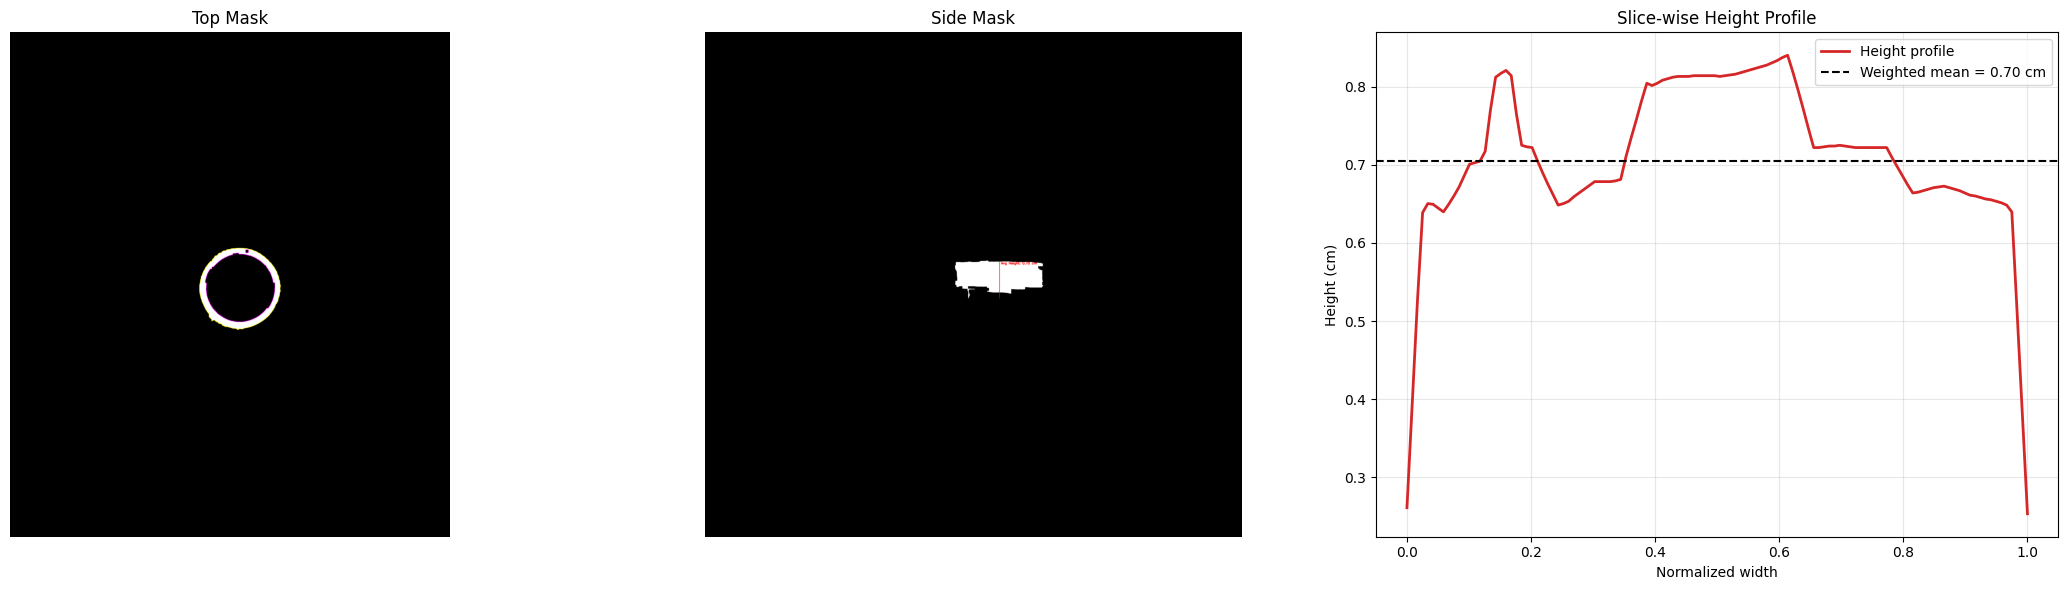

Estimated Volume (cm^3): 0.8134559746353125


In [7]:
top_seg = segment_object(
    top_view,
    view_name="Top view",
    debug=True,
    ref_square_size_px=top_ref_size_px,
    ref_square_bbox=top_ref_bbox,
    bg_similarity=0.75,
    segmentation_mode="robust",
    allow_holes=True,
    min_component_area=400,
)

side_seg = segment_object(
    side_view,
    view_name="Side view",
    debug=True,
    ref_square_size_px=side_ref_size_px,
    ref_square_bbox=side_ref_bbox,
    bg_similarity=0.75,
    edge_low=35,
    edge_high=120,
    segmentation_mode="robust",
    allow_holes=False,
    min_component_area=400,
)

volume = compute_volume_from_boundaries(
    top_seg=top_seg,
    side_seg=side_seg,
    top_scale_cm=top_scale_cm,
    side_scale_cm=side_scale_cm,
    debug=True,
)

print("Estimated Volume (cm^3):", volume)


#### Weight + Density

In [8]:
weight = 2000  # grams

In [9]:
density = weight / volume
print(f"Estimated Density: {density:.4f} g/cm^3")

Estimated Density: 2458.6457 g/cm^3


#### Purity Analysis

In [10]:
def density_to_karat_formula(D):
    """Convert density (g/cm³) to estimated karat using the fitted polynomial."""
    return 0.0089 * D**3 - 0.550 * D**2 + 12.5299 * D - 77.06


karat_density_ranges = {
    24: (19.31, 19.51),
    22: (17.45, 18.24),
    20: (16.03, 17.11),
    18: (14.84, 16.12),
    14: (12.91, 14.44),
    10: (11.42, 13.09),
}

karat_from_formula = density_to_karat_formula(density)

print("=" * 60)
print("PURITY ANALYSIS RESULTS")
print("=" * 60)
print(f"\nMeasured Density: {density:.4f} g/cm³")
print("\nMethod 1 - Polynomial Formula:")
print(f"  Estimated Karat: {karat_from_formula:.2f}K")

print("\nMethod 2 - Density Range Classification:")
found_match = False
for karat, (min_d, max_d) in sorted(karat_density_ranges.items(), reverse=True):
    if min_d <= density <= max_d:
        print(f"  ✓ Matches K{karat} range ({min_d} - {max_d} g/cm³)")
        found_match = True
        break

if not found_match:
    closest_karat = None
    min_distance = float('inf')
    for karat, (min_d, max_d) in karat_density_ranges.items():
        mid_d = (min_d + max_d) / 2
        distance = abs(density - mid_d)
        if distance < min_distance:
            min_distance = distance
            closest_karat = karat

    if closest_karat:
        min_d, max_d = karat_density_ranges[closest_karat]
        if density < min_d:
            print(f"  → Below K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")
        else:
            print(f"  → Above K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")

print("=" * 60)

PURITY ANALYSIS RESULTS

Measured Density: 2458.6457 g/cm³

Method 1 - Polynomial Formula:
  Estimated Karat: 128981032.72K

Method 2 - Density Range Classification:
  → Above K24 range (closest: 19.31 - 19.51 g/cm³)


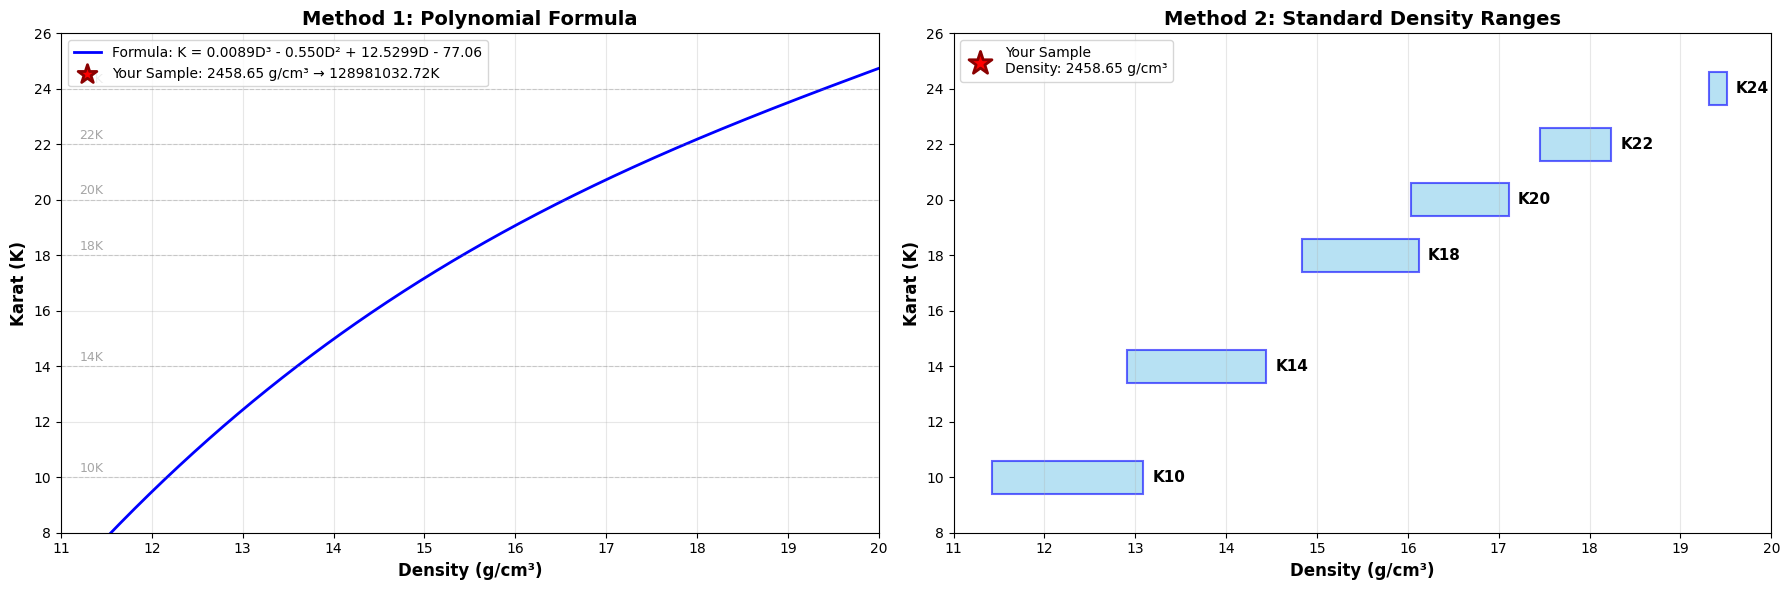


📊 Visualization complete! Both methods are displayed above.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Polynomial Formula Curve
densities_range = np.linspace(11, 20, 500)
karats_formula = [density_to_karat_formula(d) for d in densities_range]

ax1.plot(densities_range, karats_formula, 'b-', linewidth=2, label='Formula: K = 0.0089D³ - 0.550D² + 12.5299D - 77.06')
ax1.scatter([density], [karat_from_formula], color='red', s=200, zorder=5, marker='*', 
            edgecolors='darkred', linewidth=2, label=f'Your Sample: {density:.2f} g/cm³ → {karat_from_formula:.2f}K')

# Add horizontal lines for standard karats
for k in [10, 14, 18, 20, 22, 24]:
    ax1.axhline(y=k, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.text(11.2, k + 0.2, f'{k}K', fontsize=9, color='gray', alpha=0.7)

ax1.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax1.set_title('Method 1: Polynomial Formula', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xlim(11, 20)
ax1.set_ylim(8, 26)

# Plot 2: Density Range Classification
karat_values = sorted(karat_density_ranges.keys())
min_densities = [karat_density_ranges[k][0] for k in karat_values]
max_densities = [karat_density_ranges[k][1] for k in karat_values]
mid_densities = [(karat_density_ranges[k][0] + karat_density_ranges[k][1]) / 2 for k in karat_values]

# Plot density ranges as horizontal bars
for i, karat in enumerate(karat_values):
    min_d, max_d = karat_density_ranges[karat]
    ax2.barh(karat, max_d - min_d, left=min_d, height=1.2, 
             alpha=0.6, color='skyblue', edgecolor='blue', linewidth=1.5)
    ax2.text(max_d + 0.1, karat, f'K{karat}', fontsize=11, va='center', fontweight='bold')

# Plot sample point
ax2.scatter([density], [karat_from_formula], color='red', s=300, zorder=5, marker='*',
            edgecolors='darkred', linewidth=2, label=f'Your Sample\nDensity: {density:.2f} g/cm³')

# Add vertical line for sample density
ax2.axvline(x=density, color='red', linestyle='--', alpha=0.5, linewidth=2)

ax2.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax2.set_title('Method 2: Standard Density Ranges', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend(loc='best', fontsize=10)
ax2.set_xlim(11, 20)
ax2.set_ylim(8, 26)

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete! Both methods are displayed above.")